# Enterprise AI Adoption Readiness Assessment

This project presents a machine learning–based decision support tool designed to evaluate whether organizations are prepared to adopt artificial intelligence solutions.

It analyzes key factors such as industry, company size, and existing tool usage to generate a readiness score and provide actionable recommendations.

## Business Problem

Many organizations are investing in artificial intelligence, but not all are prepared to successfully implement these technologies. Without a clear understanding of readiness, companies risk wasted investment and failed adoption.

This project provides a data-driven approach to evaluate whether a company is ready to adopt AI solutions based on key organizational characteristics.

## Objective

The objective of this project is to build a machine learning model that predicts AI adoption readiness and identifies the most important factors influencing that decision.

The model is designed to support business leaders and consultants in making informed decisions about AI investments.

## Dataset

The dataset includes company-level information such as industry, company size, and AI tool usage.

It is used to simulate real-world scenarios where organizations differ in their readiness to adopt artificial intelligence technologies.

## Methodology

- Data preprocessing and feature selection
- Train-test split of the dataset
- Decision Tree classification model
- Model evaluation using accuracy and classification metrics

## Business Impact

This tool can support organizations and consulting teams by:

- Identifying companies that are ready for AI adoption
- Reducing risk associated with premature AI investments
- Highlighting key factors that influence successful AI implementation
- Supporting data-driven decision-making for technology strategy

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai_adoption_dataset.csv')

import os
print(os.getcwd())

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

pd.set_option('display.max_columns', None)
df

C:\Users\Shelly\Desktop\Capstone\ai-adoption-readiness-predictor
country: 10 unique values
industry: 8 unique values
ai_tool: 5 unique values
adoption_rate: 10001 unique values
daily_active_users: 9900 unique values
year: 2 unique values
user_feedback: 145000 unique values
age_group: 5 unique values
company_size: 3 unique values


,country,industry,ai_tool,adoption_rate,daily_active_users,year,user_feedback,age_group,company_size
0,USA,Technology,ChatGPT,40.45,2461,2023,YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...,35-44,Startup
1,France,Manufacturing,Midjourney,35.72,8496,2024,AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...,18-24,Enterprise
2,Australia,Transportation,ChatGPT,13.47,8641,2024,zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...,45-54,Startup
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...,45-54,Enterprise
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,IOQtQoSKdSmiXRsUKpjXjXZgQohymFkVUvOASXlEnVsIOS...,45-54,SME
...,...,...,...,...,...,...,...,...,...
144995,Australia,Agriculture,Midjourney,86.93,7921,2023,PxWkyTVwSNPoTXjsKzjbAFEfyJ MdgY CXjvSrkkHOTGcb...,18-24,SME
144996,Germany,Education,Midjourney,51.99,6301,2024,PtOmfGyWyZueDERRioCvbNgXomcpNNLFUjRuMEqeMrqR L...,45-54,SME
144997,USA,Finance,Stable Diffusion,47.35,4726,2023,VQuOdOKjRhchmEFrzvGlqsGOc fbTXzuzQzswt pZTCmhx...,45-54,Startup
144998,USA,Retail,ChatGPT,31.87,2481,2024,IRFOudTsoPrlrKypvToOx llYkLoLqrw EMHOtyAKmqXq...,25-34,Enterprise


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

#Load and clean the dataset
df = pd.read_csv('ai_adoption_dataset.csv', low_memory=False)
df = df.head(5000)

target_industries = ['Technology', 'Manufacturing', 'Transportation', 'Agriculture', 'Education', 'Healthcare', 'Retail', 'Finance']
df = df[df['industry'].isin(target_industries)]

for col in ['ai_tool', 'company_size']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['year'] = pd.to_numeric(df['year'], errors='coerce').fillna(df['year'].median())

df = df.dropna(subset=['adoption_rate'])

for col in ['adoption_rate', 'daily_active_users']:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df['ready_to_adopt'] = df['adoption_rate'].apply(lambda x: 1 if x >= 50 else 0)

#Industry adoption trend 
industry_year_avg = df.groupby(['industry', 'year'])['adoption_rate'].mean().reset_index()
industry_pivot = industry_year_avg.pivot(index='industry', columns='year', values='adoption_rate').reset_index()
industry_pivot.columns.name = None
industry_pivot.rename(columns={2023: 'adoption_2023', 2024: 'adoption_2024'}, inplace=True)
industry_pivot['adoption_change'] = industry_pivot['adoption_2024'] - industry_pivot['adoption_2023']

trend_map = industry_pivot.set_index('industry')['adoption_change'].to_dict()
df['industry_adoption_trend'] = df['industry'].map(trend_map)

#model
X = df[['industry', 'ai_tool', 'company_size', 'industry_adoption_trend']]
y = df['ready_to_adopt']

X_encoded = pd.get_dummies(X, columns=['industry', 'ai_tool', 'company_size'])

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.33, random_state=42)

model = DecisionTreeClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
X_test_original = df.loc[X_test.index, 'industry']
industry_probs = pd.DataFrame({'industry': X_test_original, 'prob_ready': probs})
industry_summary = industry_probs.groupby('industry')['prob_ready'].mean().sort_values(ascending=False)

print("\nEstimated AI Adoption Readiness by Industry::\n")
print(industry_summary)

y_pred = model.predict(X_test)
print("\nHow Well the Model Predicted AI Readiness:\n")
print(classification_report(y_test, y_pred, target_names=['Not Ready', 'Ready']))



Estimated AI Adoption Readiness by Industry::

industry
Finance           0.525479
Healthcare        0.491386
Agriculture       0.491030
Retail            0.490320
Transportation    0.484360
Technology        0.476170
Education         0.473820
Manufacturing     0.459250
Name: prob_ready, dtype: float64

How Well the Model Predicted AI Readiness:

              precision    recall  f1-score   support

   Not Ready       0.49      0.65      0.56       757
       Ready       0.54      0.37      0.44       828

    accuracy                           0.51      1585
   macro avg       0.52      0.51      0.50      1585
weighted avg       0.52      0.51      0.50      1585



In [12]:
#most important features of the dataset
importances = model.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("\nFeature Importances:\n")
print(feature_importance_df)



Feature Importances:

                     feature  importance
0    industry_adoption_trend    0.199585
9               ai_tool_Bard    0.156697
11            ai_tool_Claude    0.107935
8    industry_Transportation    0.098180
12        ai_tool_Midjourney    0.085643
3           industry_Finance    0.077605
15          company_size_SME    0.069245
10           ai_tool_ChatGPT    0.061363
14   company_size_Enterprise    0.052592
2         industry_Education    0.038952
16      company_size_Startup    0.037894
7        industry_Technology    0.014310
4        industry_Healthcare    0.000000
5     industry_Manufacturing    0.000000
6            industry_Retail    0.000000
1       industry_Agriculture    0.000000
13  ai_tool_Stable Diffusion    0.000000


In [13]:
#Find the average AI adoption rate for each industry in 2023 and 2024
industry_year_avg = df.groupby(['industry', 'year'])['adoption_rate'].mean().reset_index()

#Sort the top 3 most used AI tools in each industry
tool_industry = df.groupby(['industry', 'ai_tool']).size().reset_index(name='count')
top_tools = tool_industry. sort_values(['industry', 'count'], ascending=[True, False]).groupby('industry').head(3)
top_tools = top_tools.reset_index(drop=True)

print("\nTop 3 AI Tools Used In Each Industry:\n")
print(top_tools)

#Make average adoption data so 2023 and 2024 are side by side
industry_pivot = industry_year_avg.pivot(index='industry', columns='year', values='adoption_rate').reset_index()
industry_pivot.columns.name = None
industry_pivot.rename(columns={2023: 'adoption_2023', 2024: 'adoption_2024'}, inplace=True)

#Adoption rate change between 2023 and 2024
industry_pivot['adoption_change'] = industry_pivot['adoption_2024'] - industry_pivot['adoption_2023']

print("\nAdoption Rate Change from 2023 to 2024 (Positive = Increase, Negative = Decrease):\n")
print(industry_pivot[['industry', 'adoption_2023', 'adoption_2024', 'adoption_change']])

#Add this back into the dataset - it gives every company a new feature showing if they trended up or down
trend_map = industry_pivot.set_index('industry')['adoption_change'].to_dict()
df['industry_adoption_trend'] = df['industry'].map(trend_map)



Top 3 AI Tools Used In Each Industry:

          industry           ai_tool  count
0      Agriculture           ChatGPT    254
1      Agriculture        Midjourney    156
2      Agriculture  Stable Diffusion     87
3        Education           ChatGPT    257
4        Education        Midjourney    162
5        Education  Stable Diffusion     91
6          Finance           ChatGPT    231
7          Finance        Midjourney    183
8          Finance  Stable Diffusion     91
9       Healthcare           ChatGPT    230
10      Healthcare        Midjourney    196
11      Healthcare  Stable Diffusion     97
12   Manufacturing           ChatGPT    249
13   Manufacturing        Midjourney    183
14   Manufacturing  Stable Diffusion     95
15          Retail           ChatGPT    234
16          Retail        Midjourney    173
17          Retail  Stable Diffusion     74
18      Technology           ChatGPT    244
19      Technology        Midjourney    177
20      Technology  Stable Diffusion

In [21]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

title = widgets.HTML(value="<h2>Enterprise AI Adoption Readiness Assessment</h2>")
#Dict mapping industry to adoption_change
industry_adoption_trend_dict = industry_pivot.set_index('industry')['adoption_change'].to_dict()

industry_dropdown = widgets.Dropdown(
    options=list(industry_adoption_trend_dict.keys()),
    description='Industry:',
    style={'description_width': '120px'}
)

ai_tool_dropdown = widgets.Dropdown(
    options=['ChatGPT', 'Midjourney', 'Stable Diffusion', 'Bard', 'Claude'],
    description='AI Tool:',
    style={'description_width': '120px'}
)

company_size_dropdown = widgets.Dropdown(
    options=['Enterprise', 'SME', 'Startup'],
    description='Company Size:',
    style={'description_width': '120px'}
)

button = widgets.Button(description="Predict Readiness")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()

        input_dict = {
            'industry': industry_dropdown.value,
            'ai_tool': ai_tool_dropdown.value,
            'company_size': company_size_dropdown.value,
            'industry_adoption_trend': industry_adoption_trend_dict[industry_dropdown.value],
        }

        input_df = pd.DataFrame([input_dict])

        input_encoded = pd.get_dummies(input_df, columns=['industry', 'ai_tool', 'company_size'])

        for col in model.feature_names_in_:
            if col not in input_encoded.columns:
                input_encoded[col] = 0
        input_encoded = input_encoded[model.feature_names_in_]

        prob = model.predict_proba(input_encoded)[:, 1][0]

        if prob > 0.5:
            print(f"Recommendation: {input_dict['ai_tool']} is suitable for organizations in the {input_dict['industry']} sector ({input_dict['company_size']} companies).")
        else:
            print(f"Recommendation: AI adoption is not yet advised for organizations in the {input_dict['industry']} sector ({input_dict['company_size']} companies).")

        print(f"Estimated AI Adoption Readiness Score: {prob:.2%}")

button.on_click(on_button_clicked)

display(title, industry_dropdown, ai_tool_dropdown, company_size_dropdown, button, output)


HTML(value='<h2>Enterprise AI Adoption Readiness Assessment</h2>')

Dropdown(description='Industry:', options=('Agriculture', 'Education', 'Finance', 'Healthcare', 'Manufacturing…

Dropdown(description='AI Tool:', options=('ChatGPT', 'Midjourney', 'Stable Diffusion', 'Bard', 'Claude'), styl…

Dropdown(description='Company Size:', options=('Enterprise', 'SME', 'Startup'), style=DescriptionStyle(descrip…

Button(description='Predict Readiness', style=ButtonStyle())

Output()

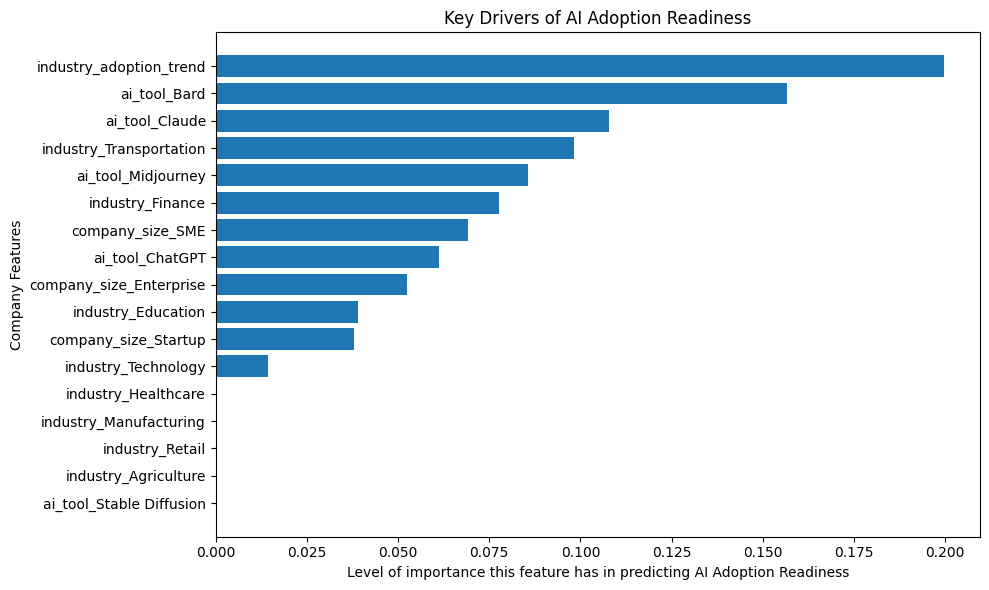

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Level of importance this feature has in predicting AI Adoption Readiness')
plt.ylabel('Company Features')
plt.title('Key Drivers of AI Adoption Readiness')
plt.tight_layout()
plt.show()


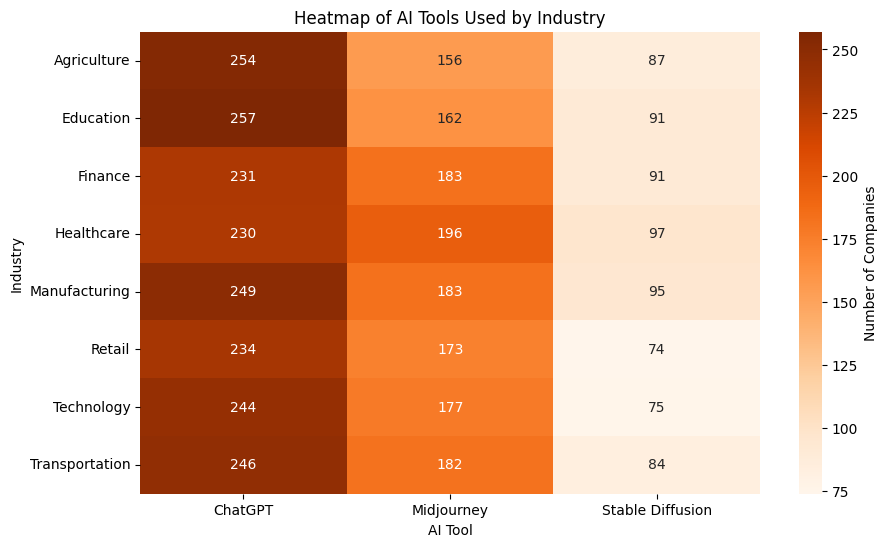

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = top_tools.pivot(index='industry', columns='ai_tool', values='count').fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='Oranges', cbar_kws={'label': 'Number of Companies'})
plt.title('Heatmap of AI Tools Used by Industry')
plt.xlabel('AI Tool')
plt.ylabel('Industry')
plt.show()


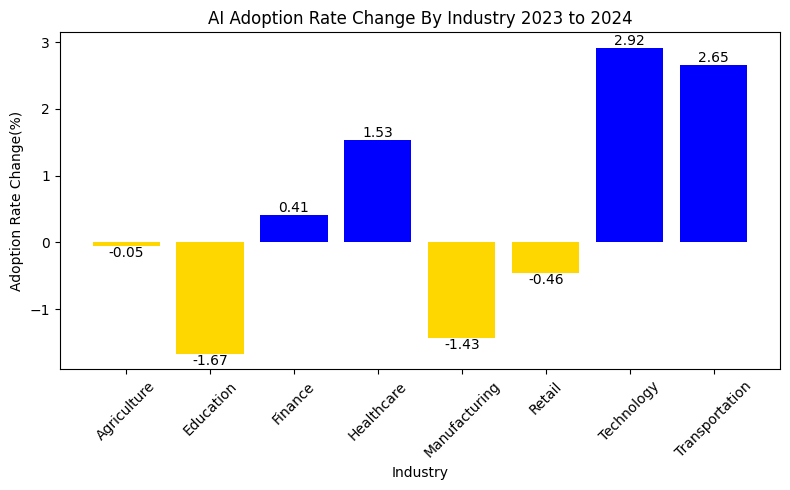

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
colors = ['gold' if value < 0 else 'blue' for value in industry_pivot['adoption_change']]
bars = plt.bar(industry_pivot['industry'], industry_pivot['adoption_change'], color=colors)

plt.title('AI Adoption Rate Change By Industry 2023 to 2024')
plt.xlabel('Industry')
plt.ylabel('Adoption Rate Change(%)')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom' if height >=0 else 'top'
    )
    
plt.tight_layout()
plt.show()

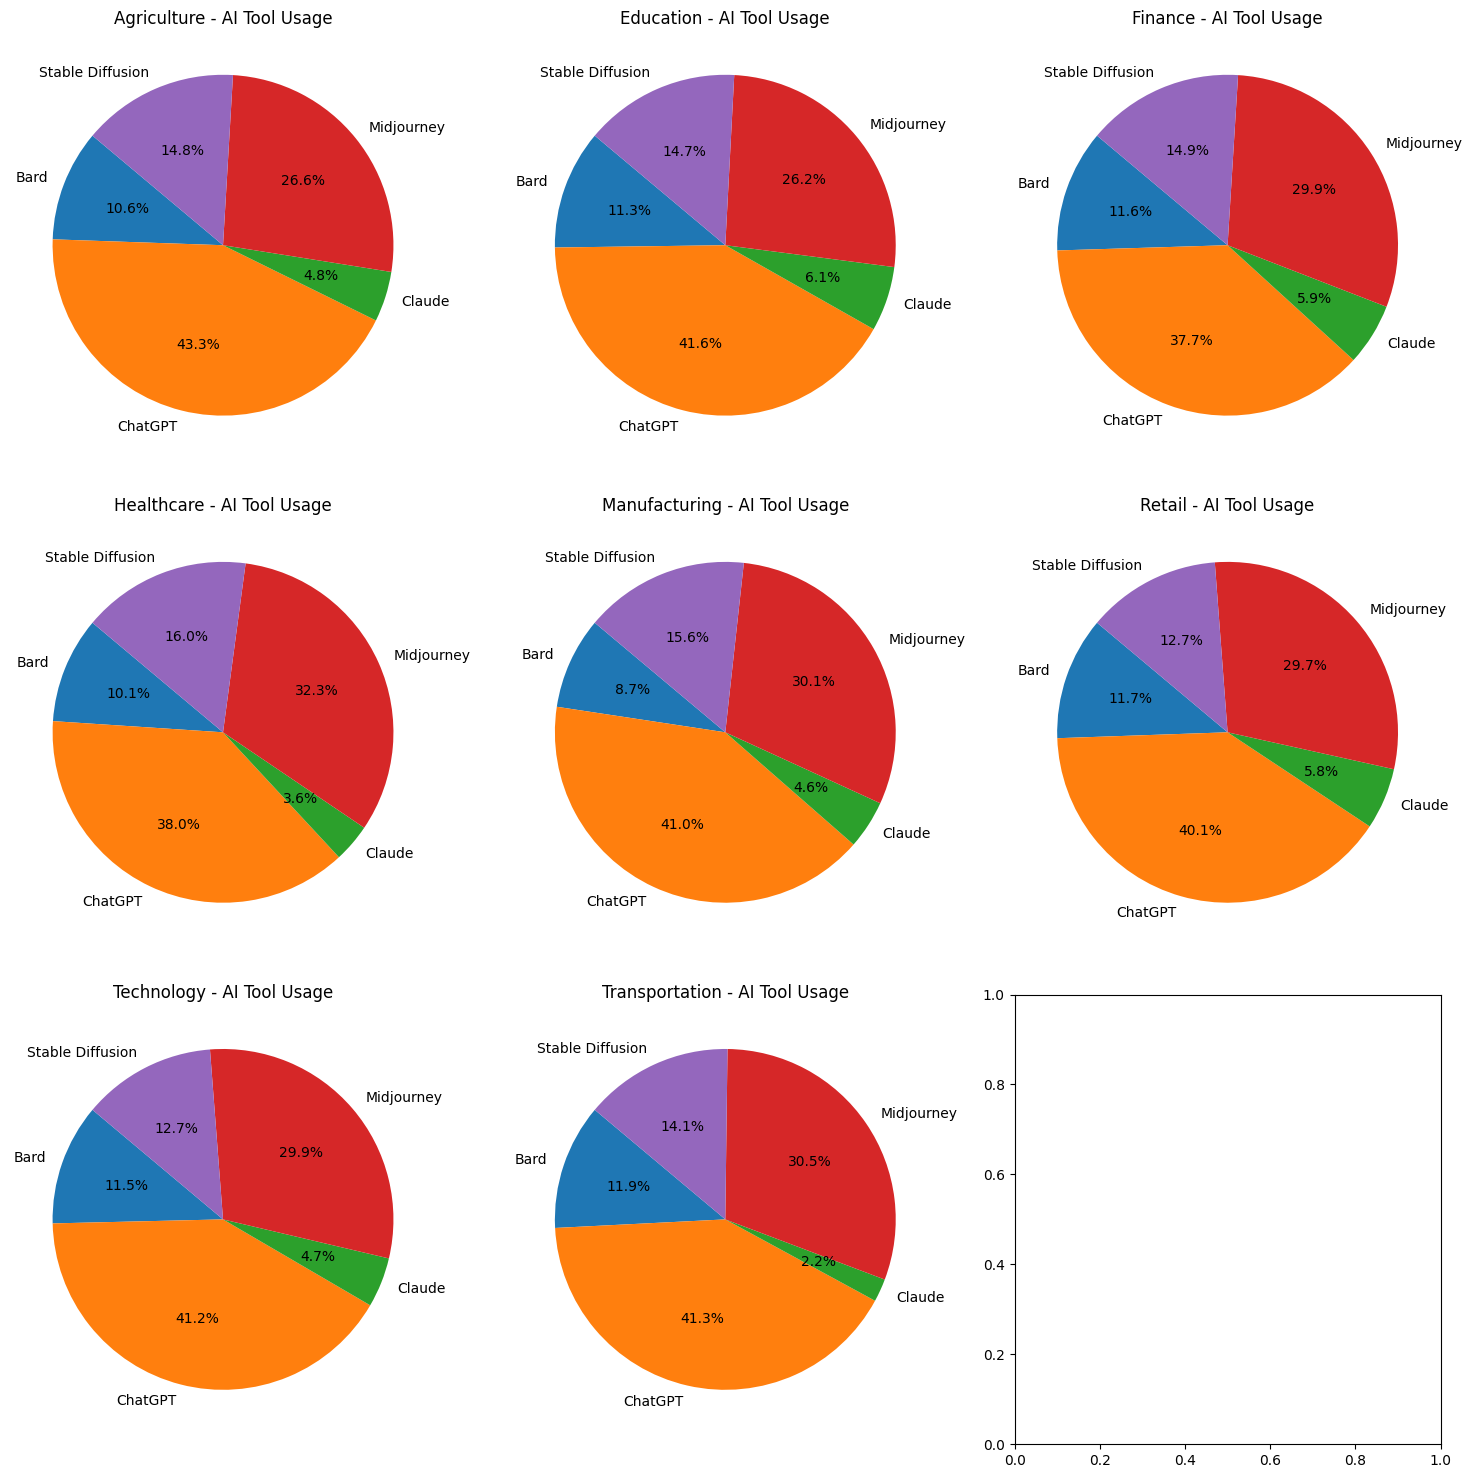

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

tool_usage = df.groupby(['industry', 'ai_tool']).size().reset_index(name='count')
industries = tool_usage['industry'].unique()

cols = 3
rows = (len(industries) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for idx, industry in enumerate(industries):
    data = tool_usage[tool_usage['industry'] == industry]
    axes[idx].pie(
        data['count'], 
        labels=data['ai_tool'],
        autopct='%1.1f%%',
        startangle=140
    )
    axes[idx].set_title(f"{industry} - AI Tool Usage")

plt.tight_layout()
plt.show()